
# Machine Learning for Application Systems
## Unit 1: Instance-based Learning & Bayesian Learning

**Topics Covered:**
- Basics of ML (Supervised, Unsupervised, Reinforcement)
- Distance Metrics (Euclidean, Manhattan, Minkowski, Cosine)
- K-Nearest Neighbors (KNN)
- Locally Weighted Regression (LWR)
- Bayes Theorem
- Naïve Bayes Classifier
- Bayesian Networks
- Applications: Spam Filter, Diabetes Diagnosis, House Price Prediction



## 1. Basics of Machine Learning

### Learning Paradigms:
- **Supervised Learning** → labeled data (classification, regression).
- **Unsupervised Learning** → unlabeled data (clustering, dimensionality reduction).
- **Reinforcement Learning** → agent-environment interaction with rewards.

We will start with supervised approaches: KNN, Regression, Naïve Bayes.


## 2. Distance Metrics

### **What Are Distance Metrics?**
Distance metrics are a key part of several machine learning algorithms. They are used in supervised and  nsupervised learning to calculate the similarity between data points. An effective distance metric improves the performance of our machine learning model, whether that’s for classification tasks or clustering.
#### **Types of Distance Metrics in Machine Learning**
- Euclidean Distance
- Manhattan Distance
- Cosine Similarity
- Minkowski Distance
- Hamming Distance



### **Euclidean Distance**
Euclidean Distance represents the shortest distance between two vectors. It is the square root of the sum of squares of differences between corresponding elements.


1. From Scratch

In [5]:
import math

def euclidean_distance_basic(point1, point2):
    """
    Calculates the Euclidean distance between two points.
    Points are expected as tuples or lists of coordinates.
    """
    if len(point1) != len(point2):
        raise ValueError("Points must have the same number of dimensions.")

    sum_sq_diff = 0
    for i in range(len(point1)):
        sum_sq_diff += (point1[i] - point2[i])**2
    return math.sqrt(sum_sq_diff)

# Example usage
p1 = (1, 2)
p2 = (4, 6)
distance = euclidean_distance_basic(p1, p2)
print(f"Euclidean distance (basic): {distance}")

p3 = (1, 2, 3)
p4 = (4, 6, 8)
distance_3d = euclidean_distance_basic(p3, p4)
print(f"Euclidean distance (3D basic): {distance_3d}")

Euclidean distance (basic): 5.0
Euclidean distance (3D basic): 7.0710678118654755


2. Using Libraries

In [12]:
from scipy.spatial import distance
euclidean_distance = distance.euclidean(p1, p2)
print('Euclidean Distance b/w', p1, 'and', p2, 'is: ', euclidean_distance)

Euclidean Distance b/w (1, 2) and (4, 6) is:  5.0


In [7]:
def manhattan_distance(point1, point2):
    """Calculates the Manhattan distance between two points."""
    if len(point1) != len(point2):
        raise ValueError("Points must have the same number of dimensions.")

    distance = 0
    for i in range(len(point1)):
        distance += abs(point1[i] - point2[i])
    return distance

# Example usage:
dist = manhattan_distance(p1, p2)
print(f"Manhattan distance: {dist}")

Manhattan distance: 7


In [14]:
manhattan_distance = distance.cityblock(p1, p2)
print('Manhattan Distance b/w', p1, 'and', p2, 'is: ', manhattan_distance)

Manhattan Distance b/w (1, 2) and (4, 6) is:  7


In [9]:
def hamming_distance_strings(str1, str2):
    """
    Calculates the Hamming distance between two strings.
    Raises ValueError if strings are of different lengths.
    """
    if len(str1) != len(str2):
        raise ValueError("Strings must be of the same length.")

    distance = 0
    for i in range(len(str1)):
        if str1[i] != str2[i]:
            distance += 1
    return distance

# Example usage
string1 = "karolin"
string2 = "kathrin"
print(f"Hamming distance between '{string1}' and '{string2}': {hamming_distance_strings(string1, string2)}")

string3 = "1011001"
string4 = "1001011"
print(f"Hamming distance between '{string3}' and '{string4}': {hamming_distance_strings(string3, string4)}")

Hamming distance between 'karolin' and 'kathrin': 3
Hamming distance between '1011001' and '1001011': 2


In [17]:
import numpy as np

def minkowski_distance(x, y, p):
  """
  Calculates the Minkowski distance between two n-dimensional points.

  Args:
    x: A NumPy array representing the first point.
    y: A NumPy array representing the second point.
    p: The order of the Minkowski distance.
       p=1 for Manhattan distance, p=2 for Euclidean distance.

  Returns:
    The Minkowski distance between x and y.
  """
  return np.sum(np.abs(x - y)**p)**(1/p)

# Example usage:
point1 = np.array([1, 2, 3])
point2 = np.array([4, 5, 6])

# Calculate Minkowski distance with p=3
distance_p3 = minkowski_distance(point1, point2, p=3)
print(f"Minkowski Distance (p=3): {distance_p3}")

# Calculate Manhattan distance (p=1)
manhattan_dist = minkowski_distance(point1, point2, p=1)
print(f"Manhattan Distance (p=1): {manhattan_dist}")

# Calculate Euclidean distance (p=2)
euclidean_dist = minkowski_distance(point1, point2, p=2)
print(f"Euclidean Distance (p=2): {euclidean_dist}")

Minkowski Distance (p=3): 4.3267487109222245
Manhattan Distance (p=1): 9.0
Euclidean Distance (p=2): 5.196152422706632


In [8]:
import numpy as np

def calculate_cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0  # Handle cases where one or both vectors are zero vectors
    return dot_product / (norm_vec1 * norm_vec2)

def calculate_cosine_distance(vec1, vec2):
    similarity = calculate_cosine_similarity(vec1, vec2)
    return 1 - similarity

# Example usage
vector_a = np.array([1, 1, 0, 1])
vector_b = np.array([1, 0, 1, 1])

similarity = calculate_cosine_similarity(vector_a, vector_b)
distance = calculate_cosine_distance(vector_a, vector_b)

print(f"Cosine Similarity: {similarity}")
print(f"Cosine Distance: {distance}")

Cosine Similarity: 0.6666666666666667
Cosine Distance: 0.33333333333333326


In [19]:
minkowski_distance_order_1 = distance.minkowski(point1, point2, p=1)
print('Minkowski Distance of order 1:',minkowski_distance_order_1)

Minkowski Distance of order 1: 9.0


### **numpy.linalg.norm**
is a function in the NumPy library for Python that calculates the norm of a vector or a matrix. In linear algebra, a norm is a function that assigns a strictly positive length or size to each vector in a vector space, and to each matrix in a matrix space. Essentially, it quantifies the "magnitude" or "length" of a vector or matrix.
 Key aspects of np.linalg.norm:
 - **Vector Norms**: Euclidean Norm (L2 Norm): This is the most common norm and what np.linalg.norm calculates by default (when ord=None and axis=None). For a vector \(v=[v_{1},v_{2},...,v_{n}]\), the L2 norm is \(\sqrt{\sum _{i=1}^{n}v_{i}^{2}}\). It represents the straight-line distance from the origin to the point represented by the vector.
  - **Other Vector Norms**: The ord parameter allows calculation of other norms, such as L1 norm (sum of absolute values), L-infinity norm (maximum absolute value), and more.

In [11]:
import numpy as np

# Two points
x = np.array([1,2])
y = np.array([4,6])

# Euclidean Distance
euclidean = np.linalg.norm(x-y)

# Manhattan Distance
manhattan = np.sum(np.abs(x-y))

# Minkowski Distance (p=3)
minkowski = np.linalg.norm(x-y, ord=3)

# Cosine Similarity
cosine = np.dot(x,y)/(np.linalg.norm(x)*np.linalg.norm(y))

euclidean, manhattan, minkowski, cosine


(np.float64(5.0),
 np.int64(7),
 np.float64(4.497941445275415),
 np.float64(0.9922778767136677))

## 3. K-Nearest Neighbors (KNN)
### 3.1 From Scratch

In [20]:

from collections import Counter

def knn(X_train, y_train, X_test, k=3):
    preds = []
    for test_point in X_test:
        distances = [np.linalg.norm(test_point - x) for x in X_train]
        k_idx = np.argsort(distances)[:k]
        k_labels = [y_train[i] for i in k_idx]
        preds.append(Counter(k_labels).most_common(1)[0][0])
    return preds


In [23]:
import numpy as np
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Predictions
y_pred = knn(X_train, y_train, X_test, k=5)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Precision: 1.0
Recall: 1.0


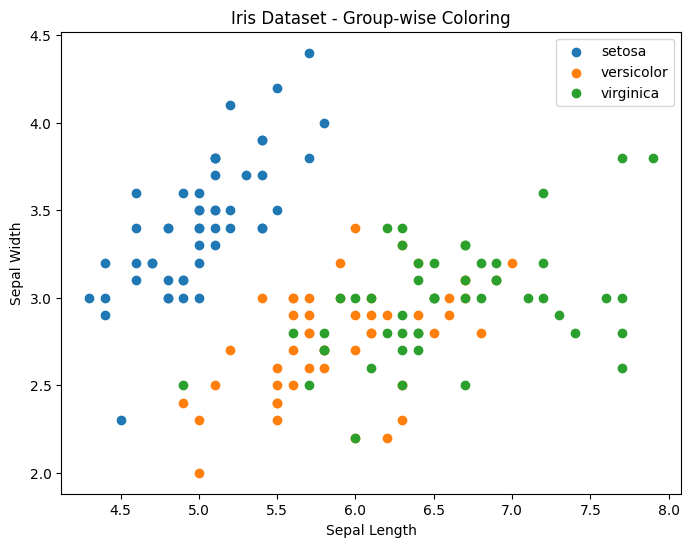

In [26]:
import matplotlib.pyplot as plt

# Take only 2 features for visualization
X_2d = iris.data[:, :2]   # Sepal length & width
y = iris.target

plt.figure(figsize=(8,6))
for i, class_name in enumerate(iris.target_names):
    plt.scatter(X_2d[y==i, 0], X_2d[y==i, 1], label=class_name)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset - Group-wise Coloring")
plt.legend()
plt.show()


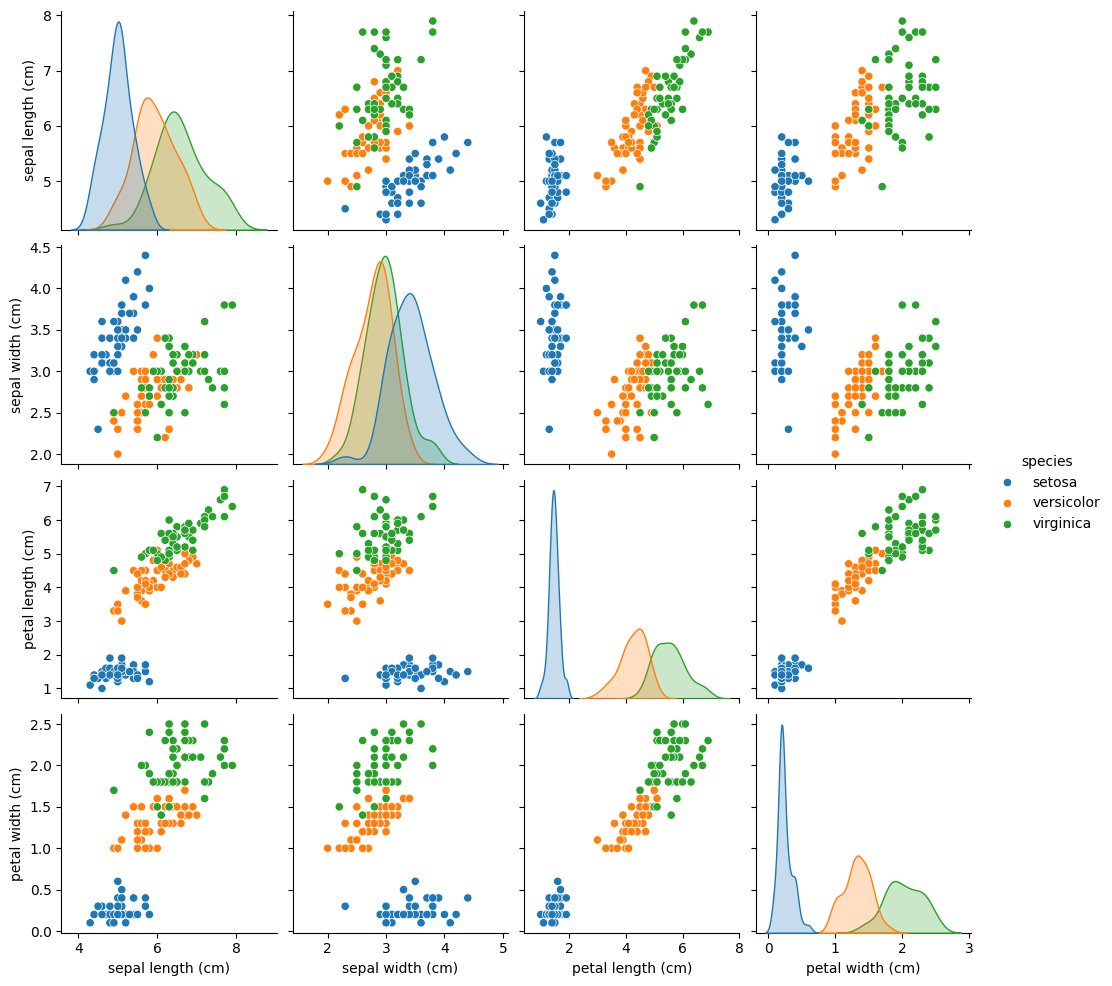

In [28]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

sns.pairplot(df, hue="species", diag_kind="kde")
plt.show()


### 3.2 With scikit-learn

In [24]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


## 4. Locally Weighted Regression (LWR)

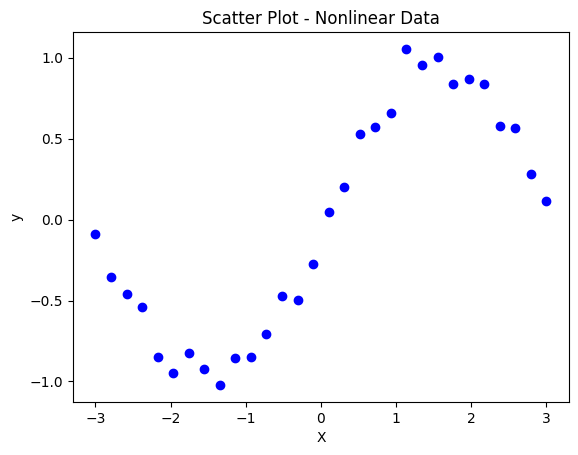

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Generate non-linear dataset ---- #
np.random.seed(42)
X = np.linspace(-3, 3, 30)[:, np.newaxis]   # shape (30,1)
y = np.sin(X) + 0.1*np.random.randn(30,1)

plt.scatter(X, y, color='blue', label='Data points')
plt.title("Scatter Plot - Nonlinear Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()



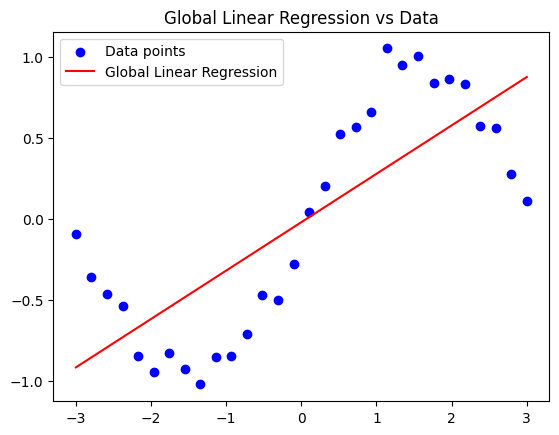

In [44]:
# ---- 2. Fit Global Linear Regression ---- #
linreg = LinearRegression()
linreg.fit(X, y)
y_global = linreg.predict(X)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_global, color='red', label='Global Linear Regression')
plt.title("Global Linear Regression vs Data")
plt.legend()
plt.show()


In [45]:

def gaussian_weight(x, xi, tau):
    return np.exp(-np.sum((x-xi)**2)/(2*tau**2))

def locally_weighted_regression(X, y, x_query, tau=0.5):
    m = X.shape[0]
    weights = np.eye(m)
    for i in range(m):
        weights[i,i] = gaussian_weight(x_query, X[i], tau)
    theta = np.linalg.pinv(X.T @ weights @ X) @ (X.T @ weights @ y)
    return x_query @ theta


In [47]:
# Predict across all X
y_lwr = [locally_weighted_regression(X, y, xq, tau=0.5) for xq in X]

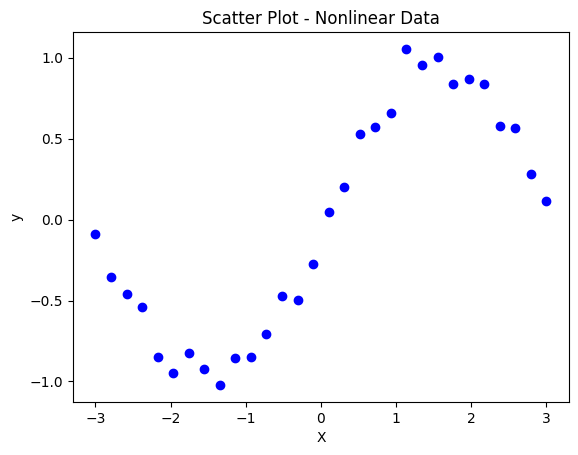

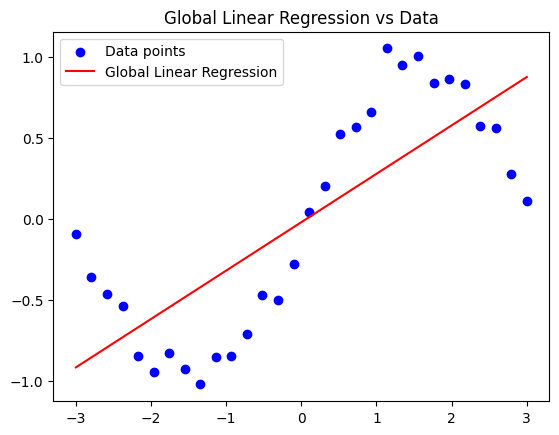

C:\Users\Administrator\AppData\Local\Temp\ipykernel_18376\439271593.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W[i,i] = np.exp(-(diff**2)/(2*tau**2))


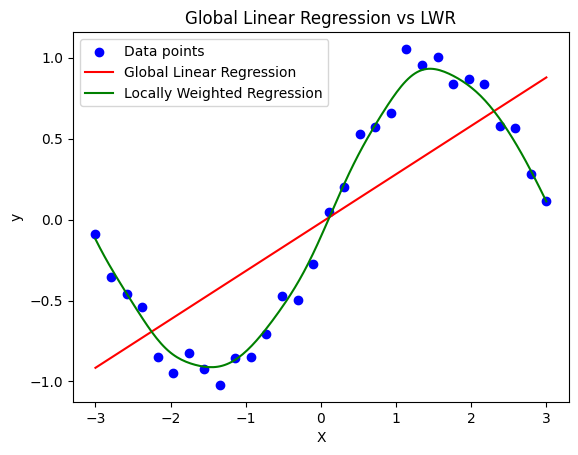

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ---- 1. Generate non-linear dataset ---- #
np.random.seed(42)
X = np.linspace(-3, 3, 30)[:, np.newaxis]   # shape (30,1)
y = np.sin(X) + 0.1*np.random.randn(30,1)

plt.scatter(X, y, color='blue', label='Data points')
plt.title("Scatter Plot - Nonlinear Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# ---- 2. Fit Global Linear Regression ---- #
linreg = LinearRegression()
linreg.fit(X, y)
y_global = linreg.predict(X)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_global, color='red', label='Global Linear Regression')
plt.title("Global Linear Regression vs Data")
plt.legend()
plt.show()

# ---- 3. Locally Weighted Regression Function ---- #
def lwr_predict(x_query, X_train, y_train, tau=0.5):
    m = X_train.shape[0]
    W = np.eye(m)
    for i in range(m):
        diff = x_query - X_train[i]
        W[i,i] = np.exp(-(diff**2)/(2*tau**2))

    X_b = np.hstack([np.ones((m,1)), X_train])
    try:
        theta = np.linalg.inv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y_train)
    except np.linalg.LinAlgError:
        theta = np.linalg.pinv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y_train)

    x_query_b = np.array([1, x_query[0]])
    return x_query_b @ theta

# ---- 4. Predict LWR across smooth X_test ---- #
X_test = np.linspace(-3,3,200)[:, np.newaxis]
y_lwr = np.array([lwr_predict(x, X, y, tau=0.3) for x in X_test])

# ---- 5. Plot comparison ---- #
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_global, color='red', label='Global Linear Regression')
plt.plot(X_test, y_lwr, color='green', label='Locally Weighted Regression')
plt.title("Global Linear Regression vs LWR")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()



## 5. Bayes Theorem

P(H|E) = [ P(E|H) * P(H) ] / P(E)

- H = Hypothesis
- E = Evidence


## 6. Naïve Bayes Classifier
### 6.1 From Scratch (Spam Filter Example)

In [50]:

import pandas as pd
from collections import defaultdict

# Simple dataset
data = pd.DataFrame({
    'Email': ["free offer", "click win", "hello friend", "meeting schedule", "win lottery"],
    'Label': ["spam", "spam", "ham", "ham", "spam"]
})

word_counts = {"spam":defaultdict(int), "ham":defaultdict(int)}
class_counts = {"spam":0, "ham":0}

for i,row in data.iterrows():
    label = row['Label']
    class_counts[label]+=1
    for word in row['Email'].split():
        word_counts[label][word]+=1

def predict_naive_bayes(email):
    words = email.split()
    probs = {}
    for c in ["spam","ham"]:
        probs[c] = class_counts[c]/sum(class_counts.values())
        for w in words:
            probs[c] *= (word_counts[c][w]+1)/(sum(word_counts[c].values())+len(words))
    return max(probs, key=probs.get)

print(predict_naive_bayes("free lottery"))
print(predict_naive_bayes("friend meeting"))


spam
ham


### 6.2 With scikit-learn

In [51]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

X = data['Email']
y = data['Label']

cv = CountVectorizer()
X_vec = cv.fit_transform(X)

nb = MultinomialNB()
nb.fit(X_vec, y)

print(nb.predict(cv.transform(["lottery offer win"])))
print(nb.predict(cv.transform(["team meeting"])))


['spam']
['ham']



## 7. Bayesian Networks

A **Bayesian Network** is a probabilistic graphical model representing dependencies among variables.

Example: Disease → Symptom  
P(Disease) = 0.01, P(Symptom|Disease) = 0.8, P(Symptom|¬Disease) = 0.1


## 8. Applications
### 8.1 Diabetes Diagnosis (KNN / Logistic Regression)

In [52]:

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, (diabetes.target>140).astype(int), test_size=0.2
)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
print("Accuracy:", logreg.score(X_test, y_test))


Accuracy: 0.7752808988764045


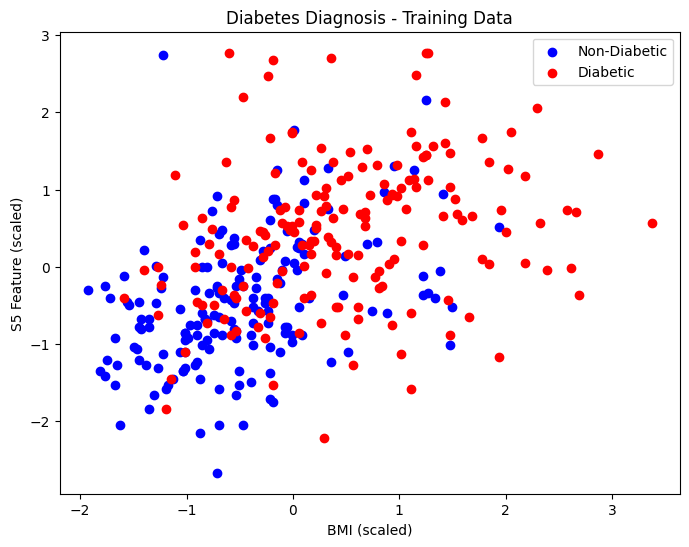

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
diabetes = load_diabetes()
X, y = diabetes.data[:, [2, 8]], (diabetes.target > 140).astype(int)  # use BMI & S5 feature, binary target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Plot data points
plt.figure(figsize=(8,6))
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], color='blue', label='Non-Diabetic')
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], color='red', label='Diabetic')
plt.xlabel("BMI (scaled)")
plt.ylabel("S5 Feature (scaled)")
plt.title("Diabetes Diagnosis - Training Data")
plt.legend()
plt.show()


In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.7078651685393258


In [57]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))


Logistic Regression Accuracy: 0.7640449438202247


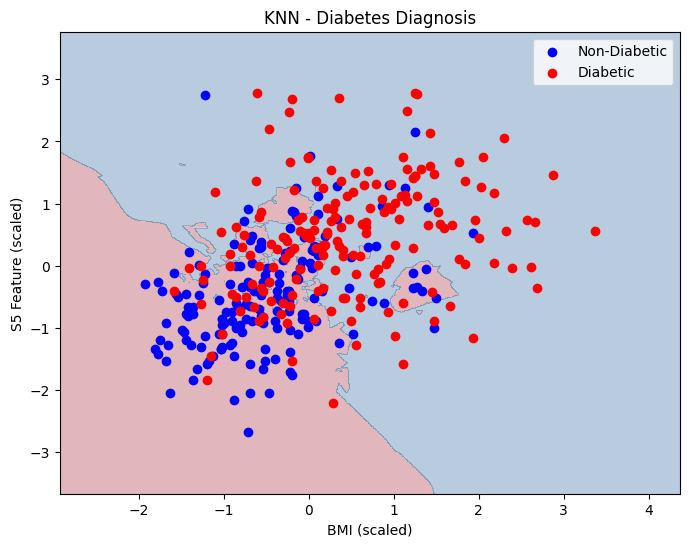

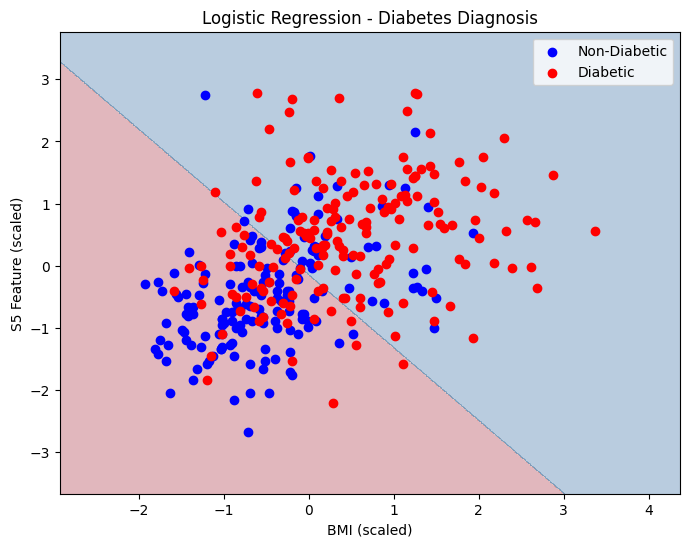

In [58]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='blue', label='Non-Diabetic')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='red', label='Diabetic')
    plt.xlabel("BMI (scaled)")
    plt.ylabel("S5 Feature (scaled)")
    plt.title(title)
    plt.legend()
    plt.show()

# KNN Decision Boundary
plot_decision_boundary(knn, X_train, y_train, "KNN - Diabetes Diagnosis")

# Logistic Regression Decision Boundary
plot_decision_boundary(logreg, X_train, y_train, "Logistic Regression - Diabetes Diagnosis")


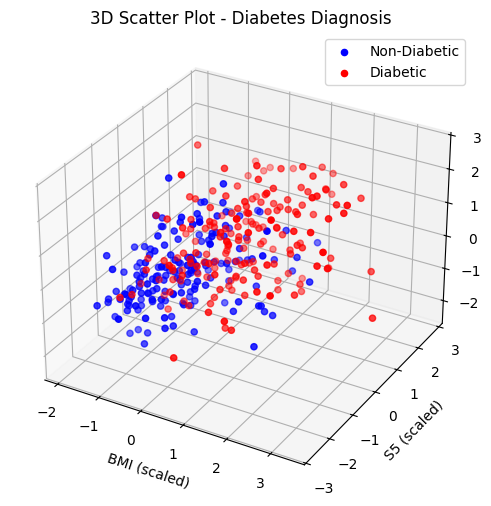

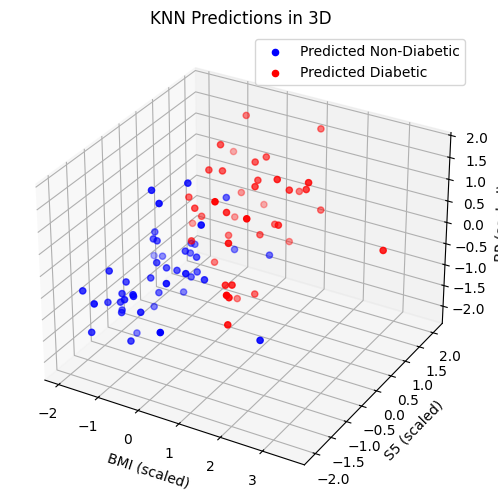

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# ---- Load dataset and create binary target ----
diabetes = load_diabetes()
X, y = diabetes.data[:, [2, 8, 3]], (diabetes.target > 140).astype(int)  # BMI, S5, BP

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---- 3D Scatter plot of training data ----
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], X_train[y_train==0][:,2], color='blue', label='Non-Diabetic')
ax.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], X_train[y_train==1][:,2], color='red', label='Diabetic')
ax.set_xlabel('BMI (scaled)')
ax.set_ylabel('S5 (scaled)')
ax.set_zlabel('BP (scaled)')
ax.set_title('3D Scatter Plot - Diabetes Diagnosis')
ax.legend()
plt.show()

# ---- Fit Models ----
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# ---- Optional: 3D prediction visualization ----
# Visualizing decision boundaries in 3D is complex, usually we use a grid of points
# Here, we can color test points by predicted label
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# KNN predictions
y_pred_knn = knn.predict(X_test)
ax.scatter(X_test[y_pred_knn==0][:,0], X_test[y_pred_knn==0][:,1], X_test[y_pred_knn==0][:,2], color='blue', label='Predicted Non-Diabetic')
ax.scatter(X_test[y_pred_knn==1][:,0], X_test[y_pred_knn==1][:,1], X_test[y_pred_knn==1][:,2], color='red', label='Predicted Diabetic')

ax.set_xlabel('BMI (scaled)')
ax.set_ylabel('S5 (scaled)')
ax.set_zlabel('BP (scaled)')
ax.set_title('KNN Predictions in 3D')
ax.legend()
plt.show()


### 8.2 House Price Prediction (Linear Regression)

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Synthetic dataset with 2 features
Size = np.random.randint(500, 3500, 15)       # size in sq.ft
Rooms = np.random.randint(1, 6, 15)          # number of rooms
Price = Size * 200 + Rooms * 10000 + np.random.randint(-20000, 20000, 15)  # linear relation + noise

# Combine into a DataFrame
data = pd.DataFrame({'Size': Size, 'Rooms': Rooms, 'Price': Price})
print(data)


    Size  Rooms   Price
0   1360      4  294747
1   1794      2  358989
2   1630      4  365118
3   1595      5  384773
4   2138      1  419499
5   2669      4  555067
6    966      2  224751
7   1738      5  388994
8    830      4  189556
9   1982      1  390290
10  2635      1  547740
11  3419      3  708302
12   630      3  157777
13  2185      2  447627
14  1269      4  282592


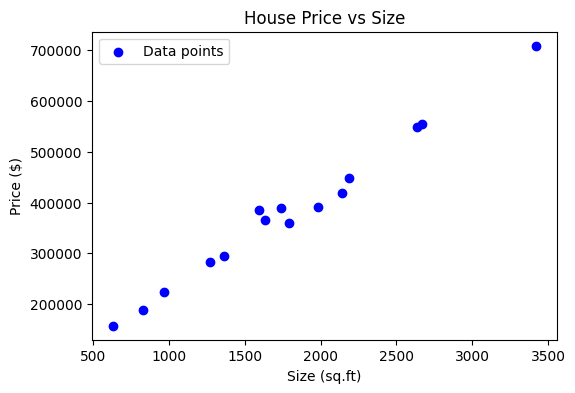

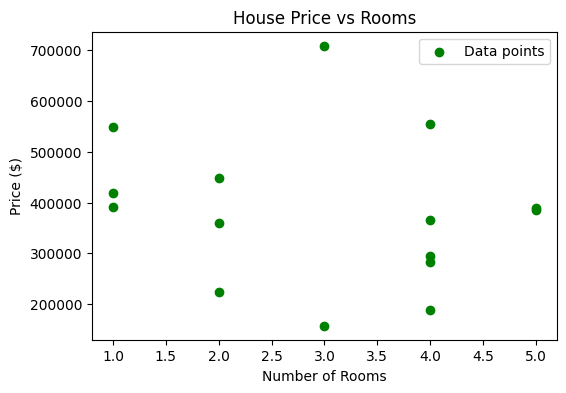

In [67]:
# Scatter plot: Size vs Price
plt.figure(figsize=(6,4))
plt.scatter(data['Size'], data['Price'], color='blue', label='Data points')
plt.xlabel('Size (sq.ft)')
plt.ylabel('Price ($)')
plt.title('House Price vs Size')
plt.legend()
plt.show()

# Scatter plot: Rooms vs Price
plt.figure(figsize=(6,4))
plt.scatter(data['Rooms'], data['Price'], color='green', label='Data points')
plt.xlabel('Number of Rooms')
plt.ylabel('Price ($)')
plt.title('House Price vs Rooms')
plt.legend()
plt.show()


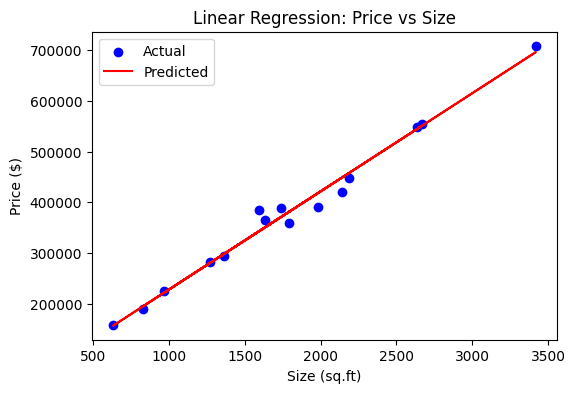

In [68]:
from sklearn.linear_model import LinearRegression

X = data[['Size']]
y = data['Price']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred, color='red', label='Predicted')
plt.xlabel('Size (sq.ft)')
plt.ylabel('Price ($)')
plt.title('Linear Regression: Price vs Size')
plt.legend()
plt.show()


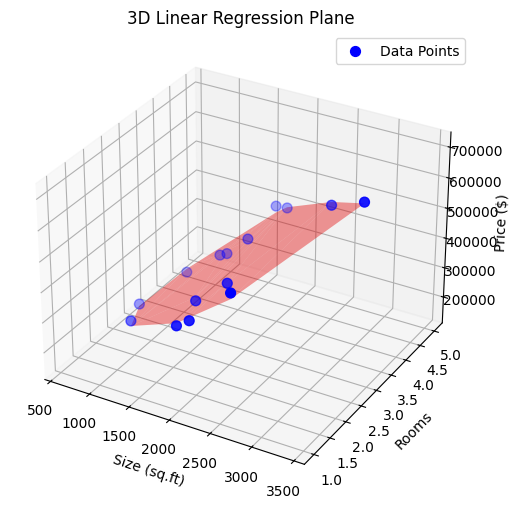

In [69]:
from mpl_toolkits.mplot3d import Axes3D

X1 = data['Size']
X2 = data['Rooms']
Y = data['Price']

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y, color='blue', s=50, label='Data Points')

# Fit regression plane
X_plane = np.column_stack((X1, X2))
reg = LinearRegression()
reg.fit(X_plane, Y)
Z_plane = reg.predict(X_plane)

ax.plot_trisurf(X1, X2, Z_plane, color='red', alpha=0.4)

ax.set_xlabel('Size (sq.ft)')
ax.set_ylabel('Rooms')
ax.set_zlabel('Price ($)')
ax.set_title('3D Linear Regression Plane')
ax.legend()
plt.show()


In [53]:

from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, test_size=0.2)

lr = LinearRegression()
lr.fit(X_train, y_train)
print("R^2 Score:", lr.score(X_test, y_test))


R^2 Score: 0.5932135259881064


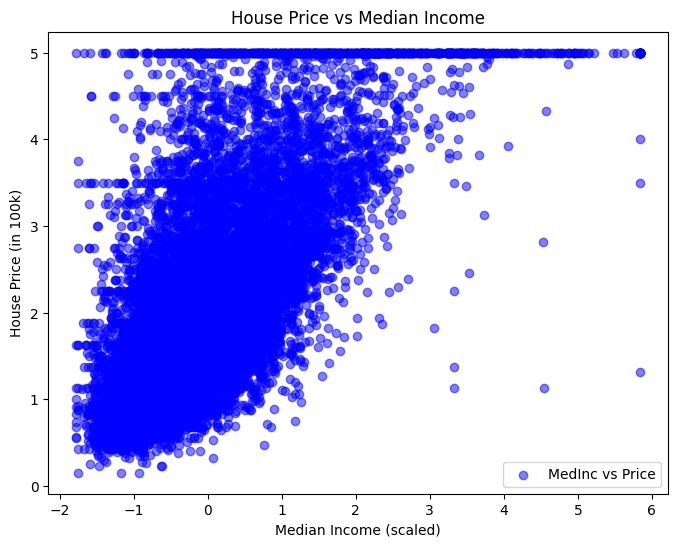

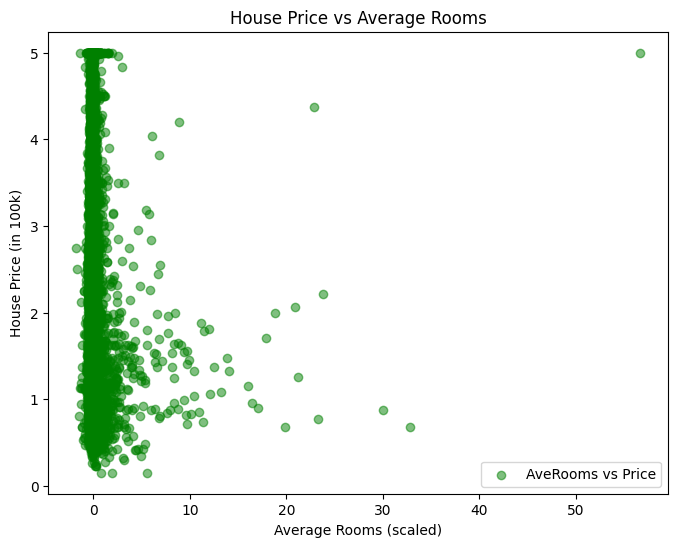

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
housing = fetch_california_housing()
X, y = housing.data[:, [0, 3]], housing.target  # MedInc, AveRooms

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling for better plotting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Plot Training Data
plt.figure(figsize=(8,6))
plt.scatter(X_train_scaled[:,0], y_train, color='blue', alpha=0.5, label='MedInc vs Price')
plt.xlabel('Median Income (scaled)')
plt.ylabel('House Price (in 100k)')
plt.title('House Price vs Median Income')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_train_scaled[:,1], y_train, color='green', alpha=0.5, label='AveRooms vs Price')
plt.xlabel('Average Rooms (scaled)')
plt.ylabel('House Price (in 100k)')
plt.title('House Price vs Average Rooms')
plt.legend()
plt.show()


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Fit model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

print("Train R^2 Score:", r2_score(y_train, y_pred_train))
print("Test R^2 Score:", r2_score(y_test, y_pred_test))


Train R^2 Score: 0.47699429245852165
Test R^2 Score: 0.4588993692089419


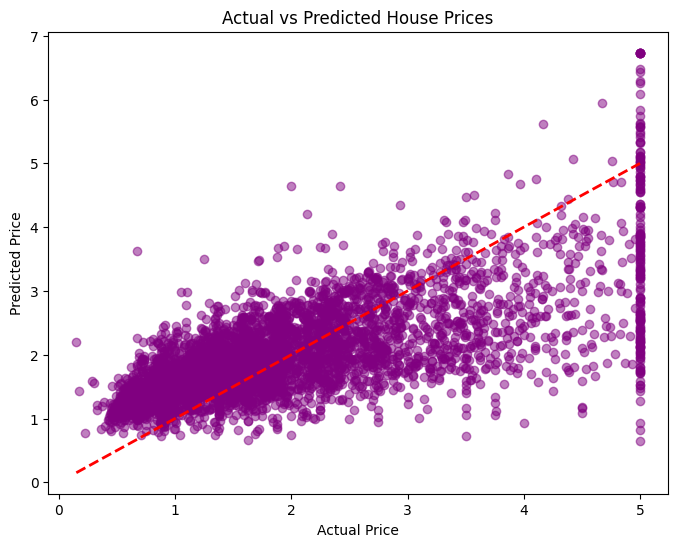

In [62]:
# Scatter plot of predicted vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test, color='purple', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect fit line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


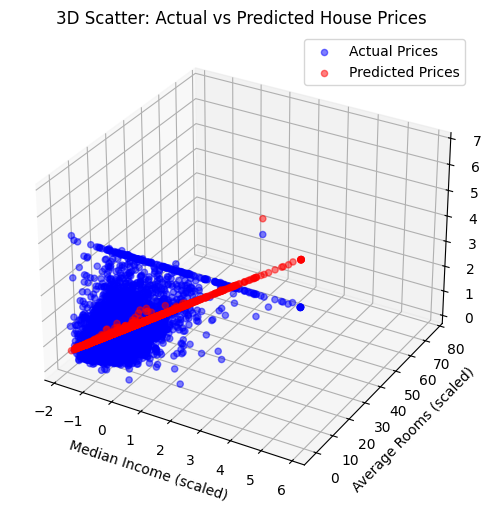

In [63]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test_scaled[:,0], X_test_scaled[:,1], y_test, color='blue', alpha=0.5, label='Actual Prices')
ax.scatter(X_test_scaled[:,0], X_test_scaled[:,1], y_pred_test, color='red', alpha=0.5, label='Predicted Prices')

ax.set_xlabel("Median Income (scaled)")
ax.set_ylabel("Average Rooms (scaled)")
ax.set_zlabel("House Price")
ax.set_title("3D Scatter: Actual vs Predicted House Prices")
ax.legend()
plt.show()


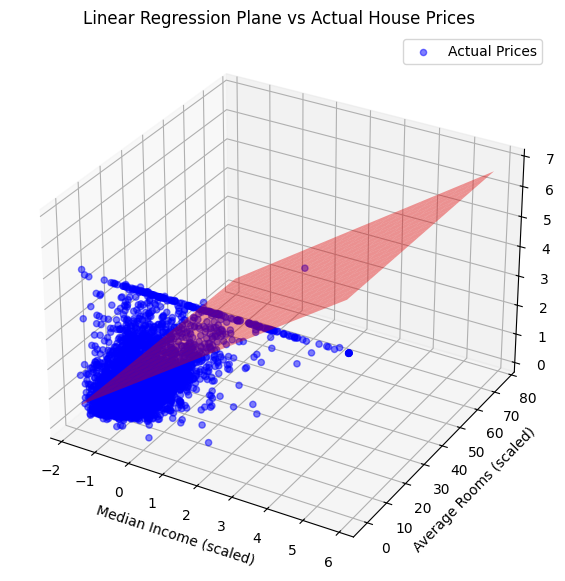

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Load data
housing = fetch_california_housing()
X, y = housing.data[:, [0, 3]], housing.target  # Median Income & Average Rooms

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# ---- 3D plot ----
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter actual points
ax.scatter(X_test_scaled[:,0], X_test_scaled[:,1], y_test, color='blue', alpha=0.5, label='Actual Prices')

# Create grid for surface
xx, yy = np.meshgrid(np.linspace(X_test_scaled[:,0].min(), X_test_scaled[:,0].max(), 20),
                     np.linspace(X_test_scaled[:,1].min(), X_test_scaled[:,1].max(), 20))
zz = lr.intercept_ + lr.coef_[0]*xx + lr.coef_[1]*yy

# Plot regression plane
ax.plot_surface(xx, yy, zz, color='red', alpha=0.4)

ax.set_xlabel("Median Income (scaled)")
ax.set_ylabel("Average Rooms (scaled)")
ax.set_zlabel("House Price")
ax.set_title("Linear Regression Plane vs Actual House Prices")
ax.legend()
plt.show()


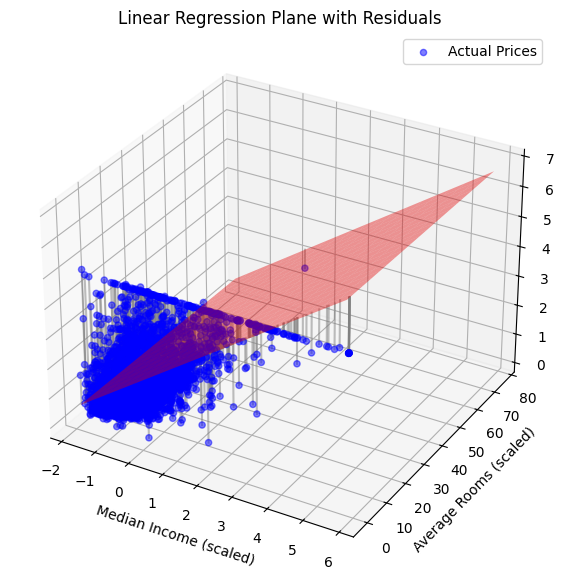

In [65]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test_scaled[:,0], X_test_scaled[:,1], y_test, color='blue', alpha=0.5, label='Actual Prices')

# Draw vertical lines to the regression plane
for i in range(len(X_test_scaled)):
    pred_z = lr.predict(X_test_scaled[i].reshape(1,-1))
    ax.plot([X_test_scaled[i,0], X_test_scaled[i,0]],
            [X_test_scaled[i,1], X_test_scaled[i,1]],
            [y_test[i], pred_z[0]], color='gray', alpha=0.5)

# Regression plane
xx, yy = np.meshgrid(np.linspace(X_test_scaled[:,0].min(), X_test_scaled[:,0].max(), 20),
                     np.linspace(X_test_scaled[:,1].min(), X_test_scaled[:,1].max(), 20))
zz = lr.intercept_ + lr.coef_[0]*xx + lr.coef_[1]*yy
ax.plot_surface(xx, yy, zz, color='red', alpha=0.4)

ax.set_xlabel("Median Income (scaled)")
ax.set_ylabel("Average Rooms (scaled)")
ax.set_zlabel("House Price")
ax.set_title("Linear Regression Plane with Residuals")
ax.legend()
plt.show()
